<a href="https://colab.research.google.com/github/shahbaz11-arch/NNDDE/blob/main/NonlinearDDE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Solving the 4x4 nonlinear algebraic system using fsolve...


/tmp/ipython-input-206/1730061252.py:123: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  w_sol_np = fsolve(algebraic_system, initial_guess)



--- Discovered Network Weights ---
w0: 1.451123
w1: 0.774818
w2: 0.586422
w3: -0.212709
w4: 0.198449
w5: -0.132377
w6: 0.083760
w7: -0.047989
w8: 0.024899
w9: -0.011601

--- Solution Evaluation (10 Test Points) ---
x     | y_approx     | y_exact (e^x)   | Relative Error 
-------------------------------------------------------
0.000 | 1.000000     | 1.000000        | 4.1389e-13     
0.062 | 1.064494     | 1.064494        | 2.7146e-11     
0.125 | 1.133148     | 1.133148        | 2.1162e-11     
0.188 | 1.206230     | 1.206230        | 1.9007e-11     
0.250 | 1.284025     | 1.284025        | 1.5854e-11     
0.312 | 1.366838     | 1.366838        | 1.3493e-11     
0.375 | 1.454991     | 1.454991        | 1.1231e-11     
0.438 | 1.548830     | 1.548830        | 9.3556e-12     
0.500 | 1.648721     | 1.648721        | 7.9979e-12     
0.562 | 1.755055     | 1.755055        | 6.8415e-12     
0.625 | 1.868246     | 1.868246        | 5.9119e-12     
0.688 | 1.988737     | 1.988737        | 4.9

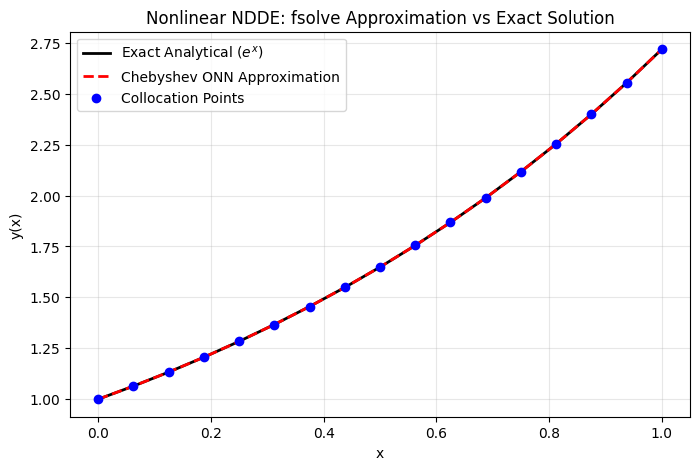

In [ ]:
# Non-linear NDDE
import torch
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

# ==========================================
# 1. Chebyshev Basis Implementation
# ==========================================
def get_chebyshev_basis(x, n_polys):
    """
    Generates Chebyshev polynomials T_n(x) and T'_n(x)
    using recurrence relations for n = 0 to n_polys-1.
    """
    if x.dim() == 0:
        x = x.unsqueeze(0)

    num_points = len(x)
    T = torch.zeros(num_points, n_polys, dtype=torch.float64)
    T_d = torch.zeros(num_points, n_polys, dtype=torch.float64)

    # Base Case: n=0 -> T_0 = 1, T'_0 = 0
    T[:, 0] = 1.0

    if n_polys > 1:
        # Base Case: n=1 -> T_1 = x, T'_1 = 1
        T[:, 1] = x
        T_d[:, 1] = 1.0

    # Recurrence Loop for n >= 2
    for n in range(2, n_polys):
        T[:, n] = 2 * x * T[:, n-1] - T[:, n-2]
        T_d[:, n] = 2 * T[:, n-1] + 2 * x * T_d[:, n-1] - T_d[:, n-2]

    return T, T_d

def predict(x, w):
    """
    Returns y_approx and y'_approx for a given set of weights.
    """
    T, T_d = get_chebyshev_basis(x, len(w))
    y = T @ w
    y_d = T_d @ w
    return y, y_d

# ==========================================
# 2. Problem Setup (LHS and RHS of NDDE)

def compute_rhs(x):
    """
    Right Hand Side of the nonlinear NDDE.
    """
    sqrt_x = torch.sqrt(x)
    sin_x = torch.sin(x)

    term1 = torch.exp(2 * x)
    term2 = torch.sqrt(torch.cos(x)) * torch.exp(sqrt_x)
    term3 = (torch.sin(sqrt_x) + torch.exp(x)) * torch.exp(sin_x)

    return term1 + term2 + term3

def compute_lhs(x, w):
    """
    Left Hand Side of the nonlinear NDDE evaluated with current weights.
    """
    y_x, yd_x = predict(x, w)

    # Delayed/Transformed states
    sqrt_x = torch.sqrt(x)
    sin_x = torch.sin(x)

    _, yd_sqrt_x = predict(sqrt_x, w)
    y_sin_x, _ = predict(sin_x, w)

    term1 = y_x * yd_x
    term2 = torch.sqrt(torch.cos(x)) * yd_sqrt_x
    term3 = (torch.sin(sqrt_x) + torch.exp(x)) * y_sin_x

    return term1 + term2 + term3

# ==========================================
# 3. System of Equations for fsolve

def algebraic_system(w_np):
    """
    Takes a numpy array of 4 weights and returns an array of 4 residuals.
    fsolve will try to drive these 4 residuals to exactly 0.
    """
    # Convert numpy array to PyTorch tensor
    w = torch.tensor(w_np, dtype=torch.float64)

    residuals = []

    # Equation 1: Initial Condition (y(0) = 1)
    x_0 = torch.tensor([0.0], dtype=torch.float64)
    y_0, _ = predict(x_0, w)
    residuals.append((y_0[0] - 1.0).item())

    # Equations 2, 3, 4: ODE Collocation at x = {0.0, 0.5, 1.0}
    colloc_points = torch.linspace(0, 1, 17, dtype=torch.float64) #(1. This needs to change)

    lhs = compute_lhs(colloc_points, w)
    rhs = compute_rhs(colloc_points)

    ode_errors = lhs - rhs

    # Append the 3 ODE errors to the residuals list
    residuals.extend(ode_errors.tolist())

    return np.array(residuals)

# ==========================================
# 4. Solve using SciPy's fsolve
# ==========================================
print("Solving the 4x4 nonlinear algebraic system using fsolve...")

# Initial guess for the weights [w0, w1, w2, w3, w4, w5] (2. This needs to change)
# We start with [1, 1, 0, 0] as a neutral guess
initial_guess = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,0.0, 0.0,0.0,0.0,
                          0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

# Run fsolve
w_sol_np = fsolve(algebraic_system, initial_guess)
w_sol = torch.tensor(w_sol_np, dtype=torch.float64)

print("\n--- Discovered Network Weights ---")
print(f"w0: {w_sol[0]:.6f}")
print(f"w1: {w_sol[1]:.6f}")
print(f"w2: {w_sol[2]:.6f}")
print(f"w3: {w_sol[3]:.6f}")
print(f"w4: {w_sol[4]:.6f}")
print(f"w5: {w_sol[5]:.6f}")
print(f"w6: {w_sol[6]:.6f}")
print(f"w7: {w_sol[7]:.6f}")
print(f"w8: {w_sol[8]:.6f}")
print(f"w9: {w_sol[9]:.6f}")

# ==========================================
# 5. Evaluate and Plot
# ==========================================
print("\n--- Solution Evaluation (10 Test Points) ---")
print(f"{'x':<5} | {'y_approx':<12} | {'y_exact (e^x)':<15} | {'Relative Error':<15}")
print("-" * 55)

x_eval = torch.linspace(0, 1, 17, dtype=torch.float64) #(3. This needs to change)
y_approx, _ = predict(x_eval, w_sol)
y_exact = torch.exp(x_eval)

rel_errors = torch.abs(y_approx - y_exact) / torch.abs(y_exact)

for i in range(len(x_eval)):
    x_val = x_eval[i].item()
    approx_val = y_approx[i].item()
    exact_val = y_exact[i].item()
    err_val = rel_errors[i].item()
    print(f"{x_val:<5.3f} | {approx_val:<12.6f} | {exact_val:<15.6f} | {err_val:<15.4e}")

# Visualization
plt.figure(figsize=(8, 5))
plt.plot(x_eval.numpy(), y_exact.numpy(), 'k-', linewidth=2, label='Exact Analytical ($e^x$)')
plt.plot(x_eval.numpy(), y_approx.numpy(), 'r--', linewidth=2, label='Chebyshev ONN Approximation')
plt.scatter(x_eval.numpy(), predict(x_eval, w_sol)[0].numpy(), color='blue', zorder=5, label='Collocation Points')
plt.title("Nonlinear NDDE: fsolve Approximation vs Exact Solution")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
import numpy as np
from scipy.optimize import fsolve

def equations(vars):
  x,y = vars
  f1 = (1 +2*x + 3*y) + 0.9368*(1+2.8284*x+6*y) + 2.2983*(1.4794 + 0.4597*x + 0.4407*y) - 7.2608
  f2 = (1+4*x+12*y)*1.7351+ 3.5597*(1.841 + 1.415*x+ 2.379*y) - 12.9743
  return [f1, f2]


guess = [0, 20] #Initial Guess
Solution = fsolve(equations, guess)
print(Solution)

[0.21661502 0.0714009 ]


--- Discovered Network Weights ---
w0: 1.175201 (Theoretical ideal: 1.250000)
w1: 1.103638 (Theoretical ideal: 1.125000)
w2: 0.357814 (Theoretical ideal: 0.250000)
w3: 0.070456 (Theoretical ideal: 0.041666)

--- Solution Evaluation (10 Test Points) ---
x     | y_approx     | y_exact (e^x)   | Relative Error 
-------------------------------------------------------
0.000 | 1.000000     | 1.000000        | 0.0000e+00     
0.100 | 1.105171     | 1.105171        | 9.8448e-15     
0.200 | 1.221403     | 1.221403        | 1.0181e-14     
0.300 | 1.349859     | 1.349859        | 8.0602e-15     
0.400 | 1.491825     | 1.491825        | 3.4233e-15     
0.500 | 1.648721     | 1.648721        | 1.6161e-15     
0.600 | 1.822119     | 1.822119        | 2.8028e-15     
0.700 | 2.013753     | 2.013753        | 3.9695e-15     
0.800 | 2.225541     | 2.225541        | 1.7959e-15     
0.900 | 2.459603     | 2.459603        | 1.4444e-15     
1.000 | 2.718282     | 2.718282        | 6.5349e-16     


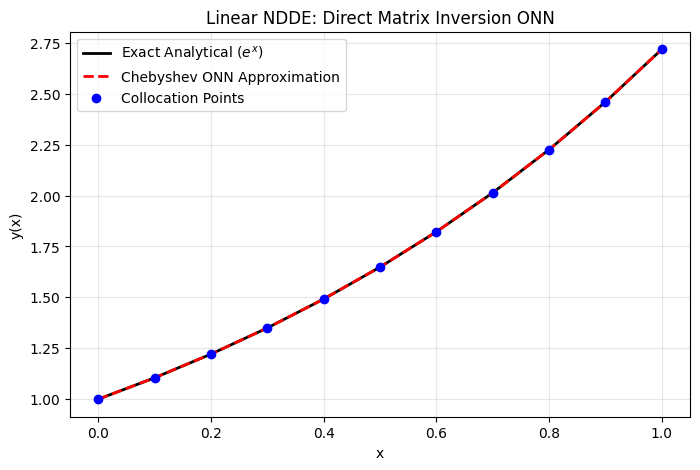

In [53]:
import torch
import matplotlib.pyplot as plt

# ==========================================
# 1. Chebyshev Basis Implementation
# ==========================================
def get_chebyshev_basis(x, n_polys):
    """
    Generates Chebyshev polynomials T_n(x) and T'_n(x)
    using recurrence relations for n = 0 to n_polys-1.
    """
    if x.dim() == 0:
        x = x.unsqueeze(0)

    num_points = len(x)
    T = torch.zeros(num_points, n_polys, dtype=torch.float64)
    T_d = torch.zeros(num_points, n_polys, dtype=torch.float64)

    # Base Case: n=0 -> T_0 = 1, T'_0 = 0
    T[:, 0] = 1.0

    if n_polys > 1:
        # Base Case: n=1 -> T_1 = x, T'_1 = 1
        T[:, 1] = x
        T_d[:, 1] = 1.0

    # Recurrence Loop for n >= 2
    for n in range(2, n_polys):
        T[:, n] = ((2*n-1) * x * T[:, n-1] - (n-1) * T[:, n-2])/n
        T_d[:, n] = ( (2*n-1)* T[:, n-1] + (2*n-1) * x * T_d[:, n-1] -(n-1)* T_d[:, n-2])/n

    return T, T_d

# ==========================================
# 2. Problem Setup (Linear NDDE)
# ==========================================
N_POLYS = 12
points_colloc = torch.linspace(0,1,11,  dtype=torch.float64)

# Initialize Square System (4 equations, 4 unknowns)
A = torch.zeros(12, N_POLYS, dtype=torch.float64)
b = torch.zeros(12, 1, dtype=torch.float64)

# --- Row 0: Initial Condition y(0) = 1 ---
T_0, _ = get_chebyshev_basis(torch.tensor([0.0], dtype=torch.float64), N_POLYS)
A[0, :] = T_0
b[0, 0] = 1.0

# --- Rows 1-3: ODE Constraints at Collocation Points ---
for i, x_val in enumerate(points_colloc):
    x = torch.tensor([x_val], dtype=torch.float64)

    # Evaluate basis at current, delayed, and transformed arguments
    T_x, Td_x = get_chebyshev_basis(x, N_POLYS)
    _, Td_sqrt_x = get_chebyshev_basis(torch.sqrt(x), N_POLYS)
    T_sin_x, _ = get_chebyshev_basis(torch.sin(x), N_POLYS)

    # Pre-compute equation coefficients for LHS
    sqrt_cos_x = torch.sqrt(torch.cos(x))
    sin_sqrt_x = torch.sin(torch.sqrt(x))
    exp_x = torch.exp(x)

    # LHS: Sum( w_n * [T'_n(x) + sqrt(cos(x))T'_n(sqrt(x)) + (sin(sqrt(x)) + e^x)T_n(sin(x))] )
    coeffs = Td_x + sqrt_cos_x * Td_sqrt_x + (sin_sqrt_x + exp_x) * T_sin_x
    A[i+1, :] = coeffs

    # RHS: e^x + sqrt(cos(x))e^(sqrt(x)) + (sin(sqrt(x)) + e^x)e^(sin(x))
    rhs = exp_x + sqrt_cos_x * torch.exp(torch.sqrt(x)) + (sin_sqrt_x + exp_x) * torch.exp(torch.sin(x))
    b[i+1, 0] = rhs

# ==========================================
# 3. Solve for Weights (Direct Matrix Inversion)
# ==========================================
# Because the ODE is linear, we can use torch.linalg.solve to find exact analytical weights
weights = torch.linalg.solve(A, b)

print("--- Discovered Network Weights ---")
print(f"w0: {weights[0].item():.6f} (Theoretical ideal: 1.250000)")
print(f"w1: {weights[1].item():.6f} (Theoretical ideal: 1.125000)")
print(f"w2: {weights[2].item():.6f} (Theoretical ideal: 0.250000)")
print(f"w3: {weights[3].item():.6f} (Theoretical ideal: 0.041666)")

# ==========================================
# 4. Evaluate Solution and Relative Error
# ==========================================
print("\n--- Solution Evaluation (10 Test Points) ---")
print(f"{'x':<5} | {'y_approx':<12} | {'y_exact (e^x)':<15} | {'Relative Error':<15}")
print("-" * 55)

x_eval = torch.linspace(0, 1, 11, dtype=torch.float64)
T_eval, _ = get_chebyshev_basis(x_eval, N_POLYS)

# Calculate approximate and exact solutions
y_approx = (T_eval @ weights).flatten()
y_exact = torch.exp(x_eval)

rel_errors = torch.abs(y_approx - y_exact) / torch.abs(y_exact)

for i in range(len(x_eval)):
    x_val = x_eval[i].item()
    approx_val = y_approx[i].item()
    exact_val = y_exact[i].item()
    error_val = rel_errors[i].item()

    print(f"{x_val:<5.3f} | {approx_val:<12.6f} | {exact_val:<15.6f} | {error_val:<15.4e}")

# Visualization
plt.figure(figsize=(8, 5))
plt.plot(x_eval.numpy(), y_exact.numpy(), 'k-', linewidth=2, label='Exact Analytical ($e^x$)')
plt.plot(x_eval.numpy(), y_approx.numpy(), 'r--', linewidth=2, label='Chebyshev ONN Approximation')
plt.scatter(points_colloc.numpy(), (get_chebyshev_basis(points_colloc, N_POLYS)[0] @ weights).flatten().numpy(),
            color='blue', zorder=5, label='Collocation Points')
plt.title("Linear NDDE: Direct Matrix Inversion ONN")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()